In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# RK4 function

In [3]:
#Define the function
def RK4(t1, theta_0, v_0, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    E = np.zeros(n)
    
    g = 9.81
    m = 1
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v_0
    E[0] = 0.5 * m * v_0**2 + m * g * l * (1-np.cos(theta_0))
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    
    #Loop over the time values and calculate the derivatives
    for i in range(1,n): 
        
        # Calculate the Runge - Kutta intermediate values
        f1 = h * F(theta[i-1])
        f2 = h * F(theta[i-1]+f1/2)
        f3 = h * F(theta[i-1]+f2/2)
        f4 = h * F(theta[i-1]+f3)
        
        g1 = h * G(v[i-1])
        g2 = h * G(v[i-1]+g1/2)
        g3 = h * G(v[i-1]+g2/2)
        g4 = h * G(v[i-1]+g3)
        
        theta[i] = theta[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
        v[i] = v[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        E[i] = 0.5 * m * v[i]**2 + m*g*l*(1-np.cos(theta[i]))
        
        
        
        
    return(t,theta,v,E) 

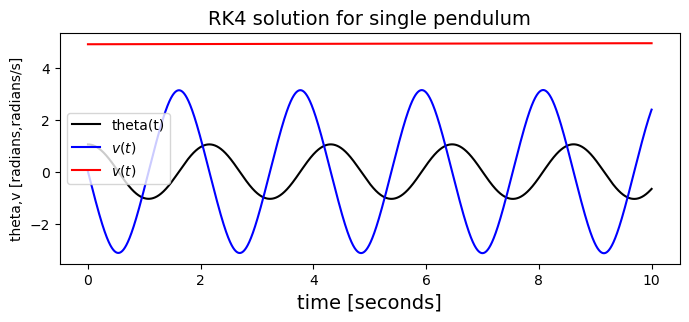

In [17]:
t,theta,v,E = RK4(10,np.pi/3,0,1,0.0001)

plt.figure(figsize = (8,3))
plt.title('RK4 solution for single pendulum', size = 14)

plt.plot(t,theta, label = 'theta(t)', color = 'black')
plt.plot(t,v, label = '$v(t)$', color = 'blue')
plt.plot(t,E, label = '$v(t)$', color = 'red')
plt.xlabel('time [seconds]', size = 14)
plt.ylabel('theta,v [radians,radians/s]')
plt.legend()



plt.show()

In [46]:
peaks = find_peaks(theta)
peaks = t[peaks[0:-1]]
peaks

array([2.1534, 4.307 , 6.4609, 8.6151])

# Different initial angles - RK4

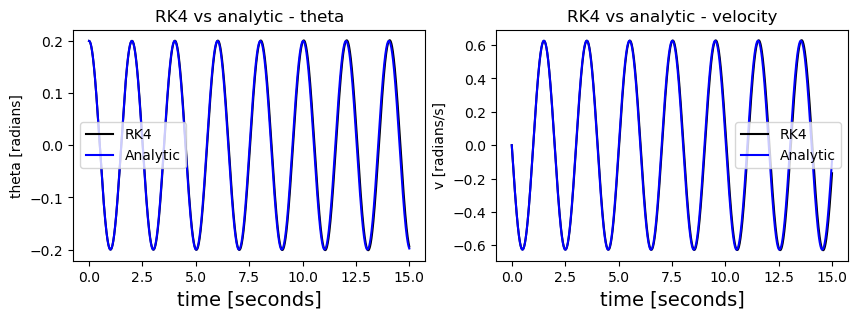

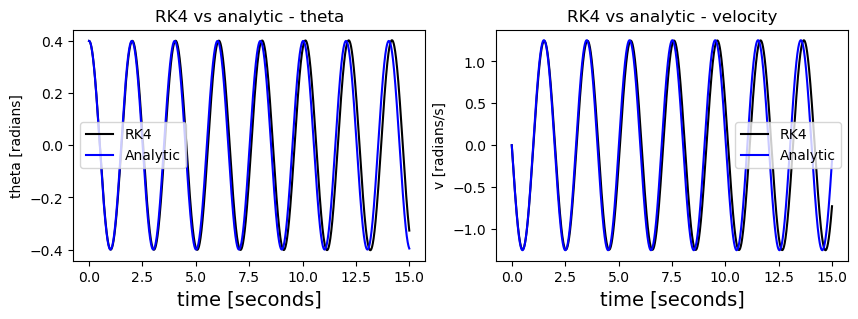

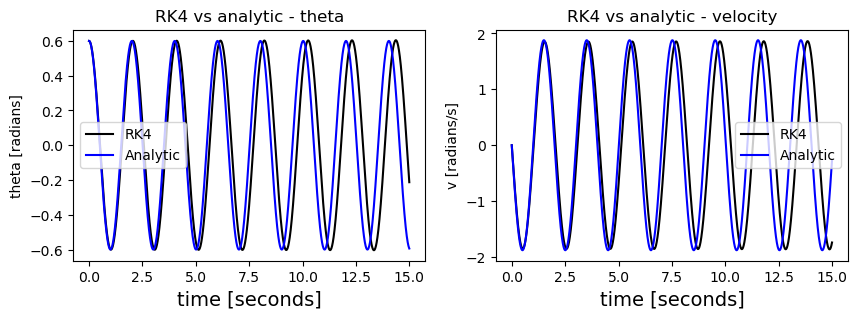

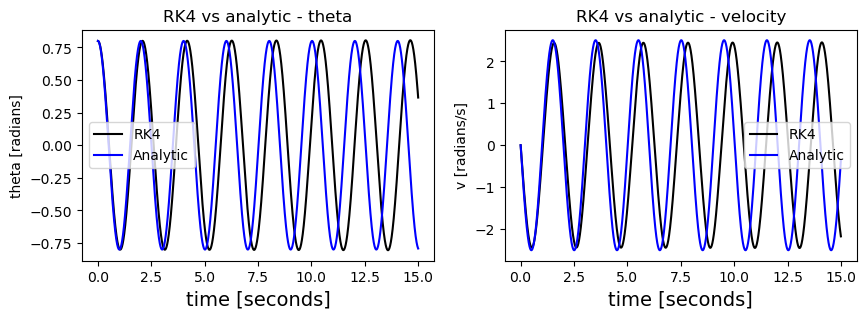

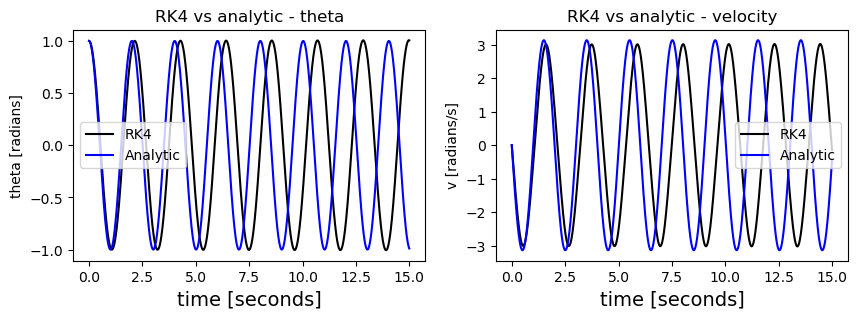

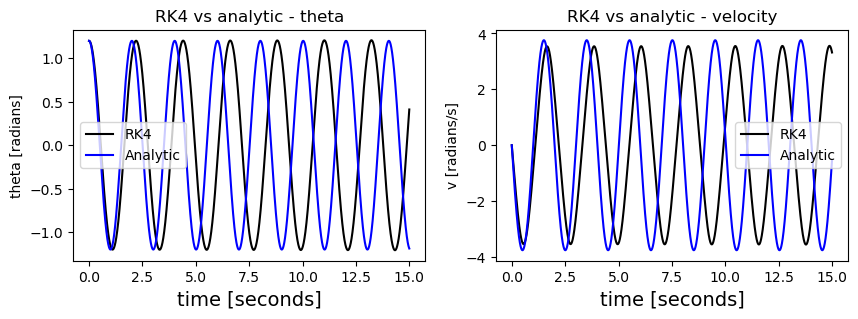

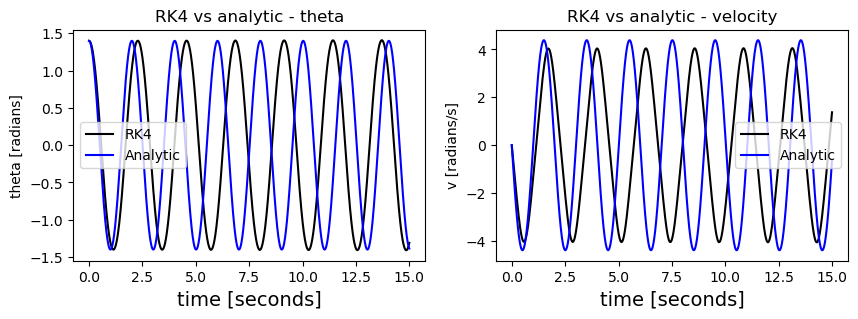

In [17]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t,theta,v,E = RK4(15,i,0,1,0.0001)
    analytic_theta = i * np.cos(np.sqrt(9.81/1)*t)
    analytic_v = -i * np.sqrt(9.81)* np.sin(np.sqrt(9.81)*t)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK4 vs analytic - theta')
    plt.plot(t,theta, label = 'RK4', color = 'black')
    plt.plot(t,analytic_theta, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK4 vs analytic - velocity')
    plt.plot(t,v, label = 'RK4', color = 'black')
    plt.plot(t,analytic_v, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

Can see from the graphs that as the initial angle is increased, the period of the RK4 solution differs more greatly from the analytic.

# Different lengths - RK4

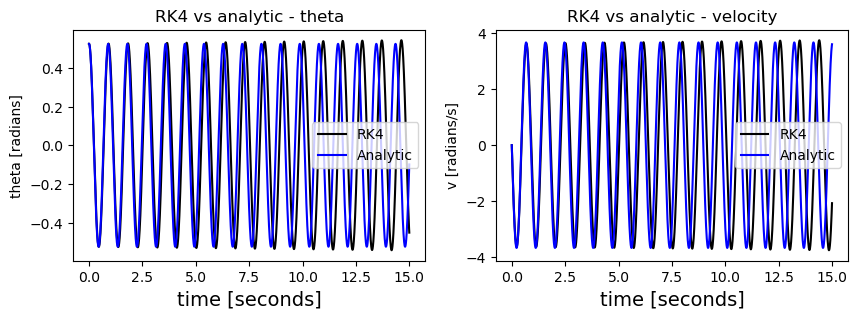

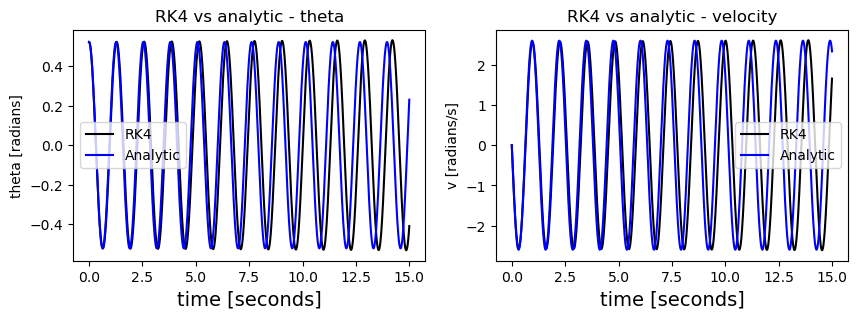

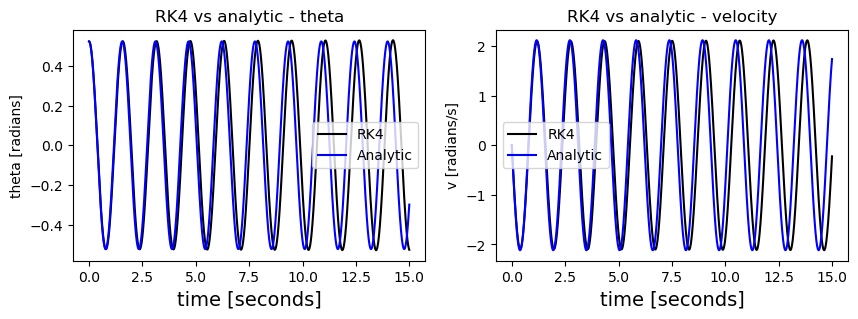

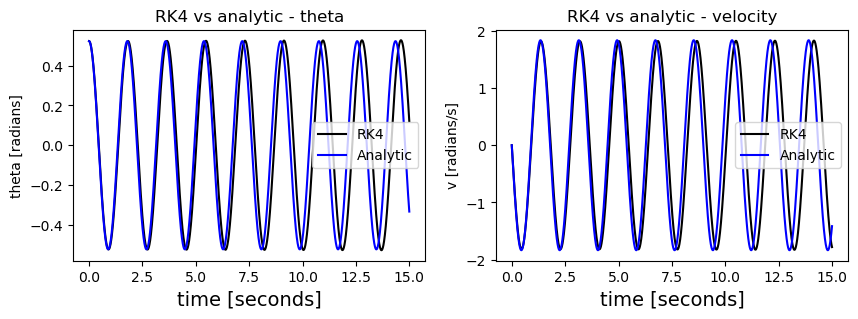

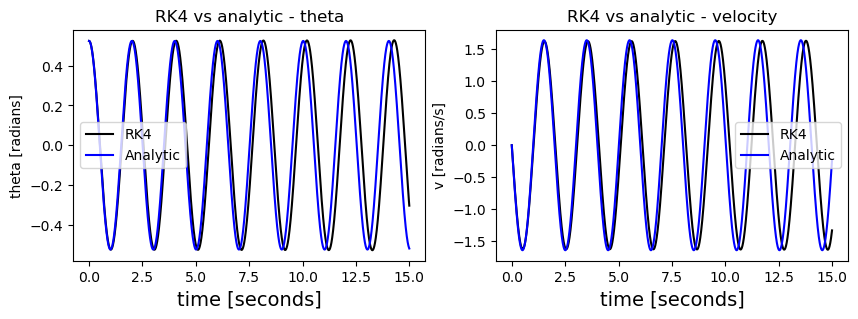

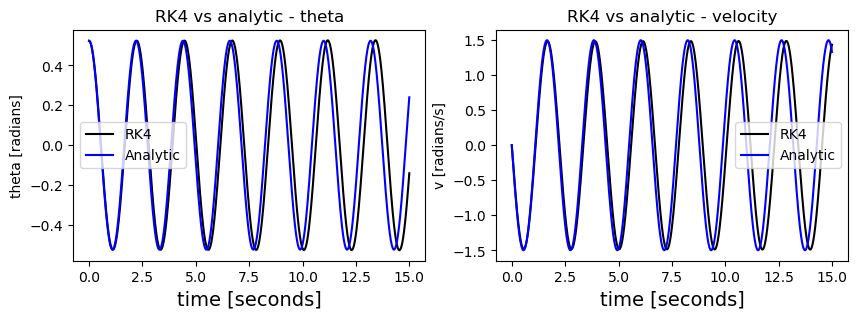

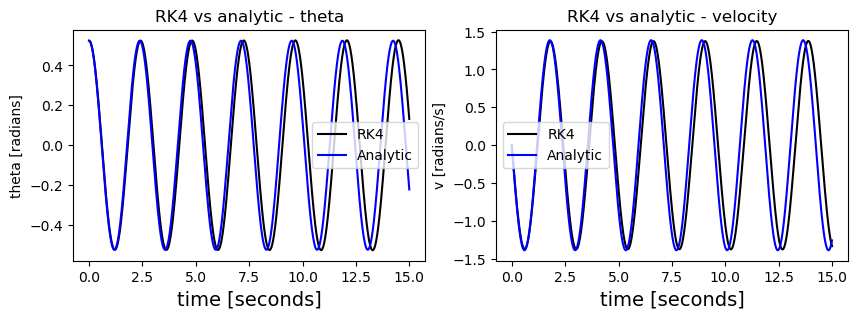

In [23]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t,theta,v,E = RK4(15,np.pi/6,0,i,0.0001)
    analytic_theta = np.pi/6 * np.cos(np.sqrt(9.81/i)*t)
    analytic_v = -np.pi/6 * np.sqrt(9.81/i)* np.sin(np.sqrt(9.81/i)*t)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK4 vs analytic - theta')
    plt.plot(t,theta, label = 'RK4', color = 'black')
    plt.plot(t,analytic_theta, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK4 vs analytic - velocity')
    plt.plot(t,v, label = 'RK4', color = 'black')
    plt.plot(t,analytic_v, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

# RK6 function

In [31]:
def RK6(t1, theta_0, v_0,l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    E = np.zeros(n)
    
    g  = 9.81
    m = 1
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v_0
    E[0] = 0.5 * m * v_0**2 + m * g * l * (1-np.cos(theta_0))
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    for i in range(1, n):
        
        k1_v = h * F(theta[i-1])
        k1_theta = h * G(v[i-1])

        k2_v = h * F(theta[i-1] + k1_theta / 4)
        k2_theta = h * G(v[i-1] + k1_v / 4)

        k3_v = h * F(theta[i-1] + k2_theta / 4)
        k3_theta = h * G(v[i-1] + k2_v / 4)

        k4_v = h * F(theta[i-1] + k3_theta / 2)
        k4_theta = h * G(v[i-1] + k3_v / 2)

        
        k5_v = h * F(theta[i-1] - k4_theta + 2 * k3_theta)
        k5_theta = h * G(v[i-1] - k4_v + 2 * k3_v)

        k6_v = h * F(theta[i-1] + (7 * k1_theta + 6 * k2_theta + 8 * k3_theta + 3 * k4_theta) / 14)
        k6_theta = h * G(v[i-1] + (7 * k1_v + 6 * k2_v + 8 * k3_v + 3 * k4_v) / 14)



        # RK6 weights
        theta[i] = theta[i-1] + (7 * k1_theta + 32 * k3_theta + 12 * k4_theta + 32 * k5_theta + 7 * k6_theta) / 90
        v[i] = v[i-1] + (7 * k1_v + 32 * k3_v + 12 * k4_v + 32 * k5_v + 7 * k6_v) / 90
        E[i] = 0.5 * m * v[i]**2 + m*g*l*(1-np.cos(theta[i]))
        
        if theta[i] >= 2*np.pi:
            theta[i] = theta[i]-2*np.pi

    return t,theta,v,E

# Different initial angles - RK6

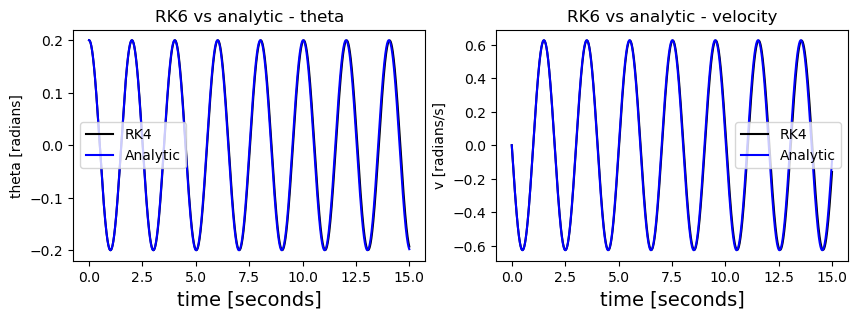

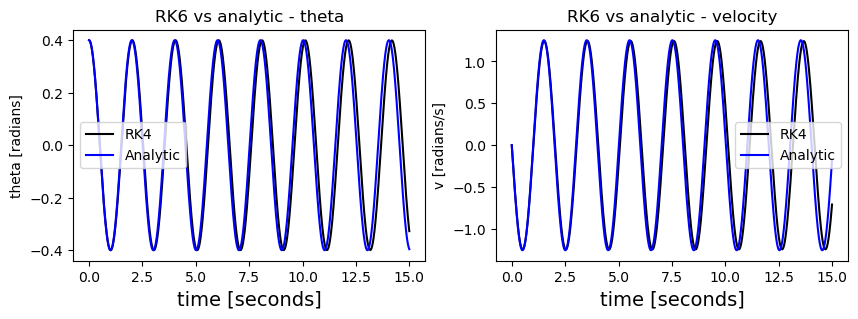

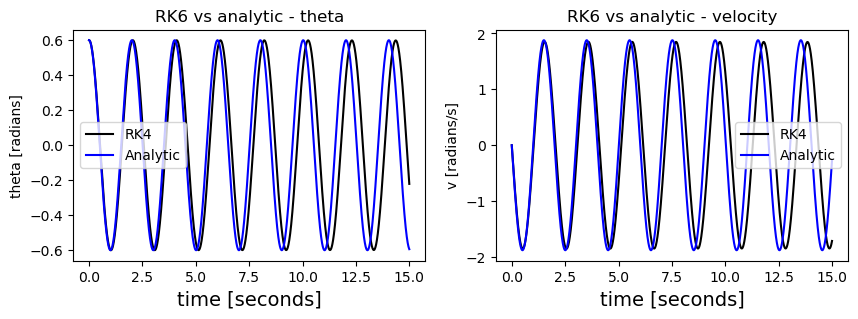

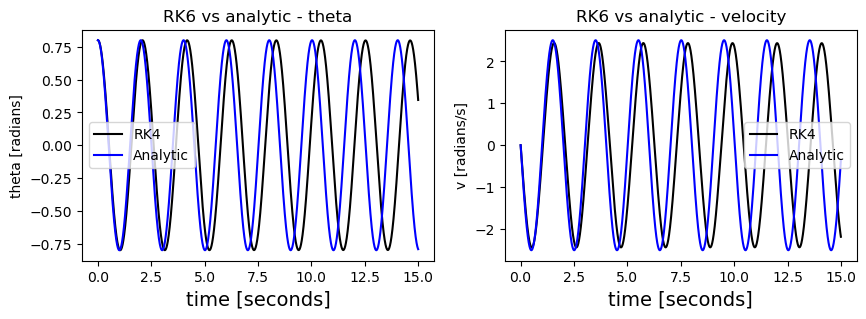

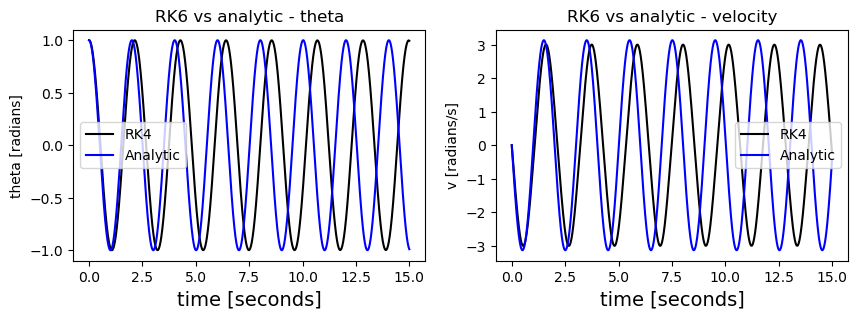

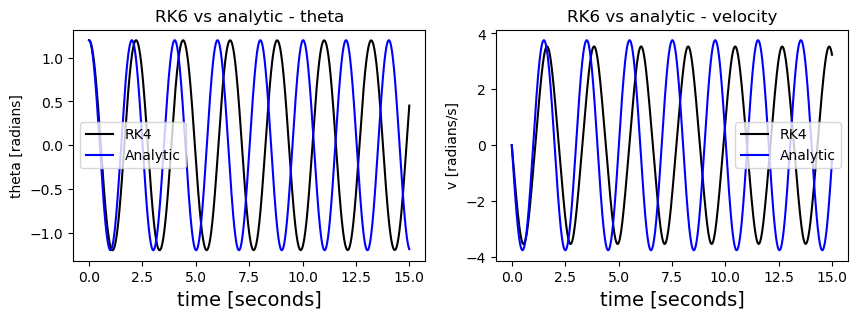

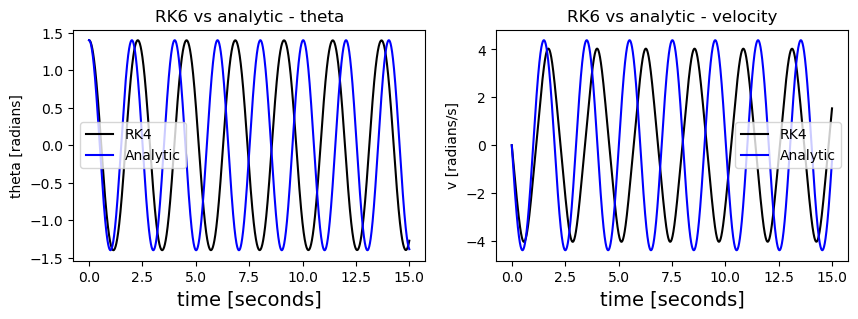

In [32]:
for i in [0.2,1.4]:

    t,theta,v,E = RK6(15,i,0,1,0.0001)
    analytic_theta = i * np.cos(np.sqrt(9.81/1)*t)
    analytic_v = -i * np.sqrt(9.81/1)* np.sin(np.sqrt(9.81/1)*t)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK6 vs analytic - theta')
    plt.plot(t,theta, label = 'RK4', color = 'black')
    plt.plot(t,analytic_theta, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK6 vs analytic - velocity')
    plt.plot(t,v, label = 'RK4', color = 'black')
    plt.plot(t,analytic_v, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

# Different lengths - RK6

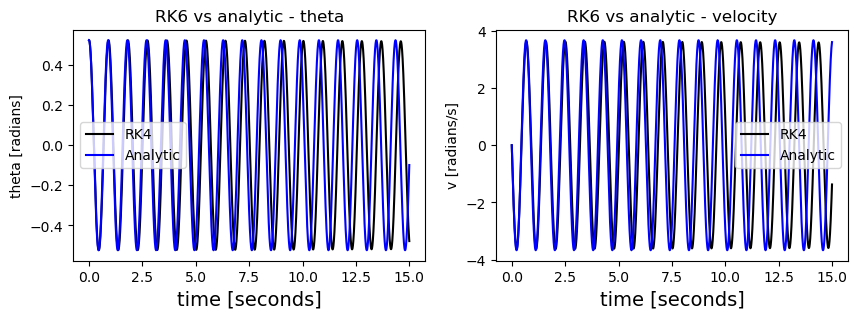

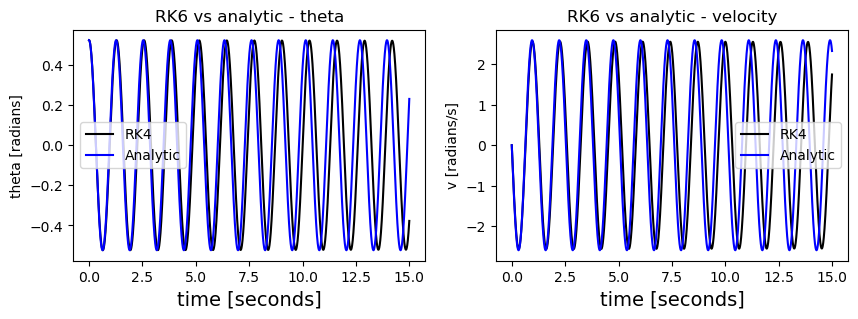

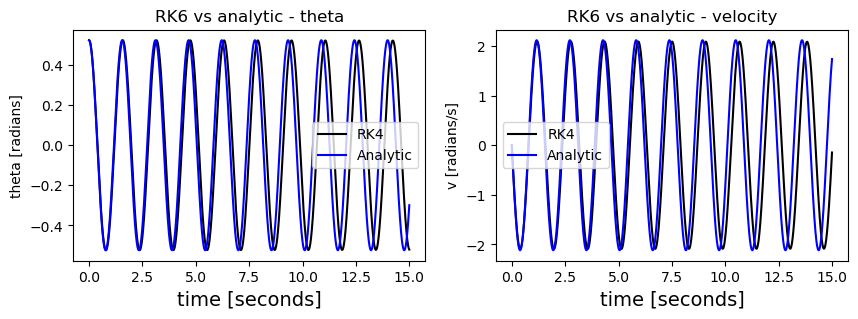

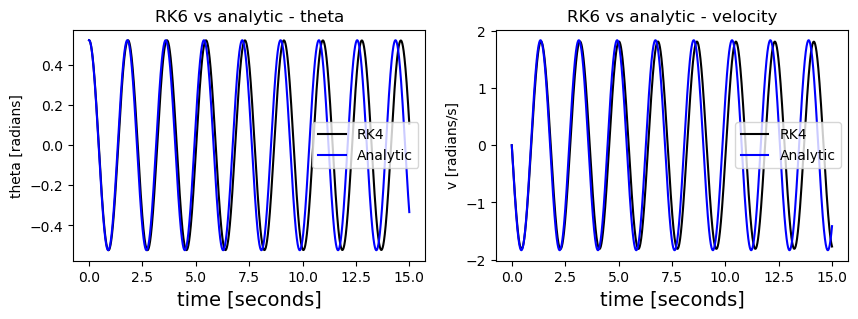

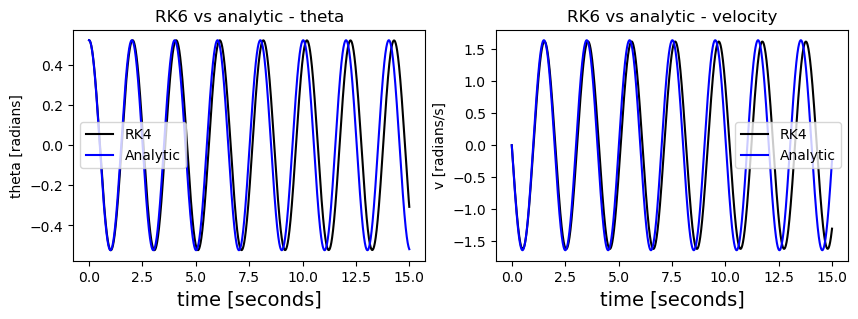

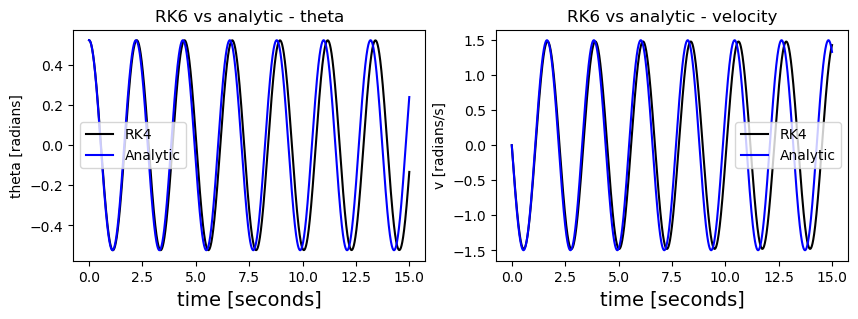

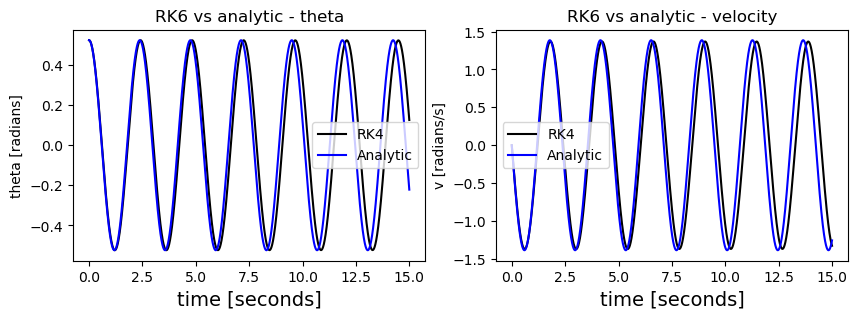

In [33]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t,theta,v,E = RK6(15,np.pi/6,0,i,0.0001)
    analytic_theta = np.pi/6 * np.cos(np.sqrt(9.81/i)*t)
    analytic_v = -np.pi/6 * np.sqrt(9.81/i)* np.sin(np.sqrt(9.81/i)*t)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK6 vs analytic - theta')
    plt.plot(t,theta, label = 'RK4', color = 'black')
    plt.plot(t,analytic_theta, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK6 vs analytic - velocity')
    plt.plot(t,v, label = 'RK4', color = 'black')
    plt.plot(t,analytic_v, label = 'Analytic', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

# Different initial angles - RK4 v RK6

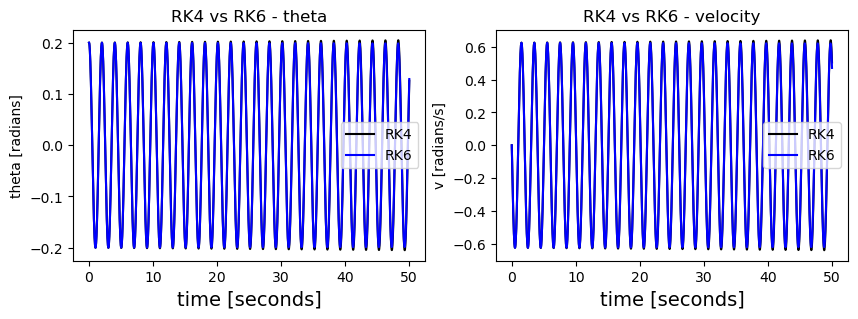

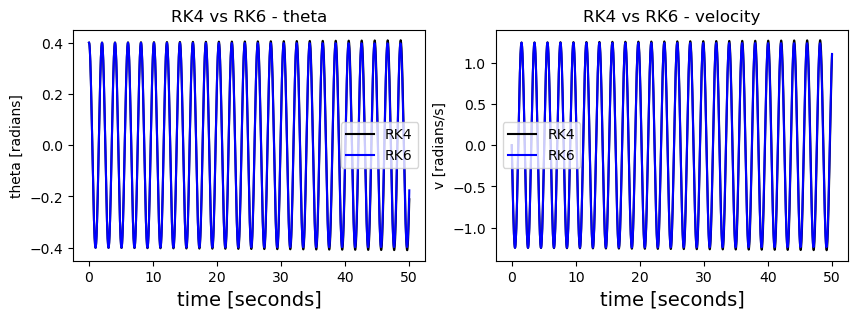

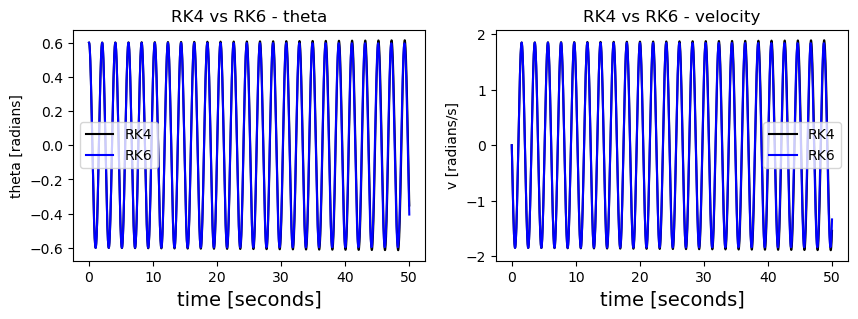

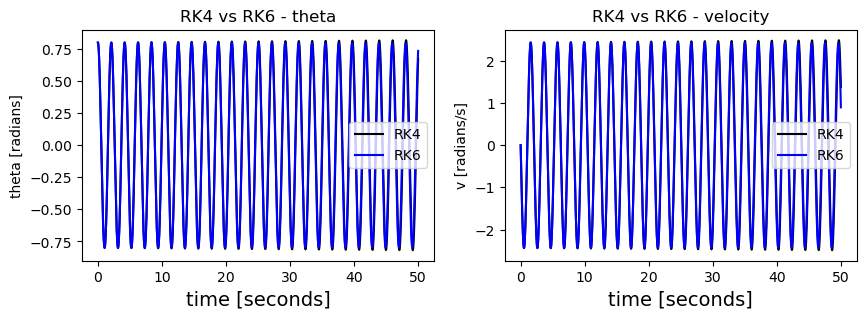

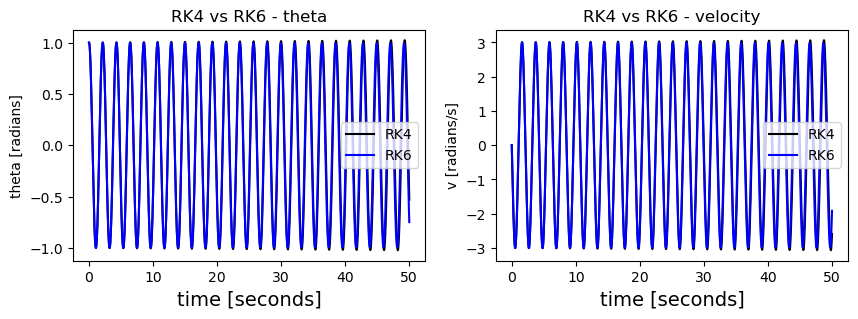

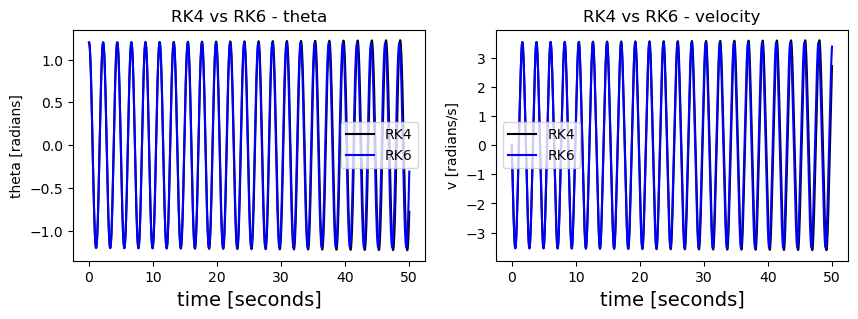

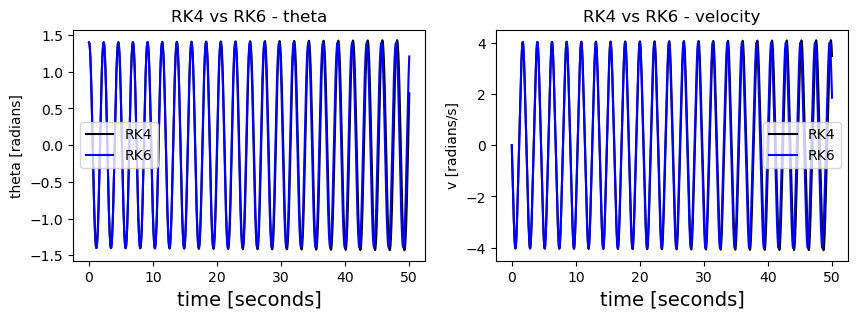

In [34]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t1,theta1,v1,E1 = RK4(50,i,0,1,0.0001)
    t2,theta2,v2, E2 = RK6(50,i,0,1,0.0001)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK4 vs RK6 - theta')
    plt.plot(t1,theta1, label = 'RK4', color = 'black')
    plt.plot(t2,theta2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK4 vs RK6 - velocity')
    plt.plot(t1,v1, label = 'RK4', color = 'black')
    plt.plot(t2,v2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

# Different initial velocities - RK4 v RK6

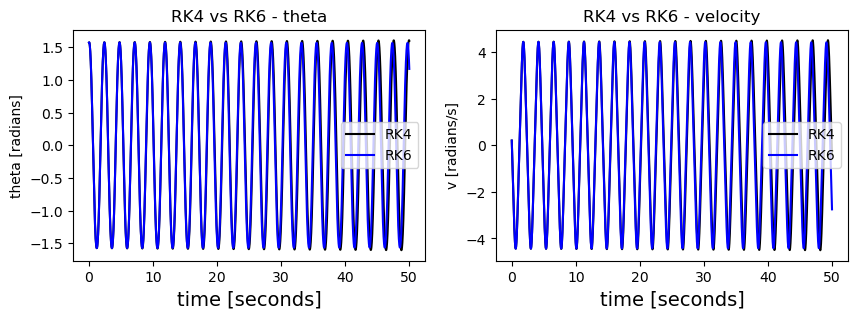

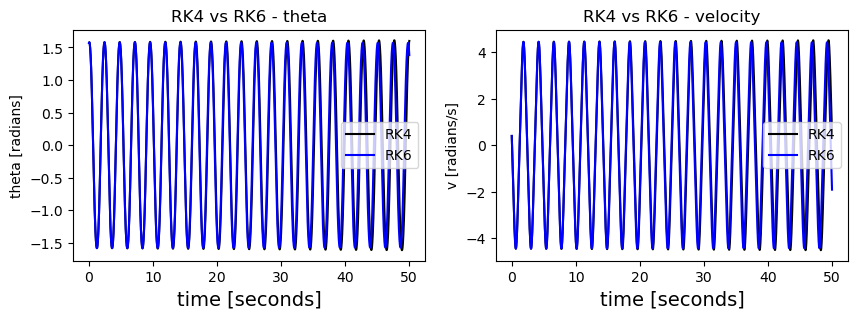

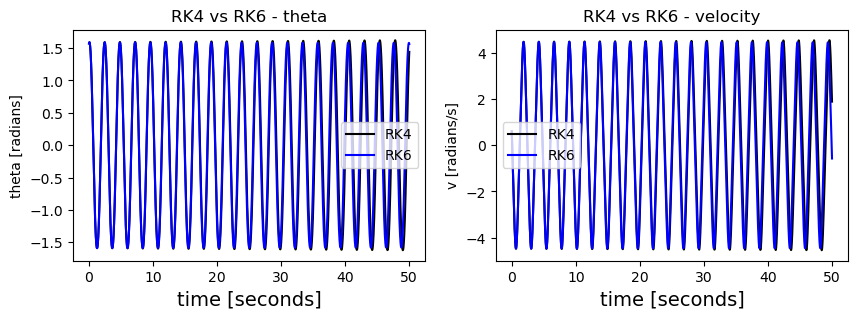

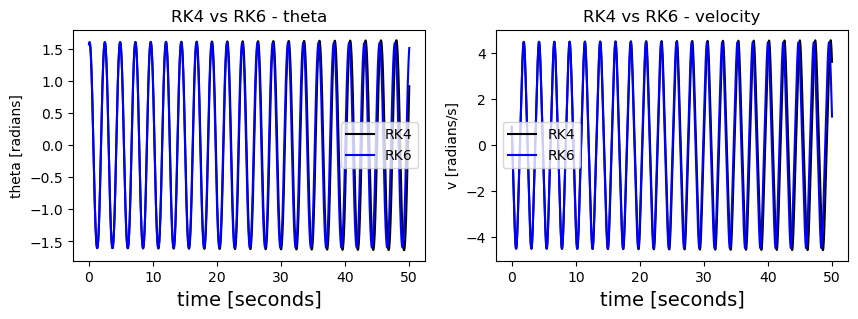

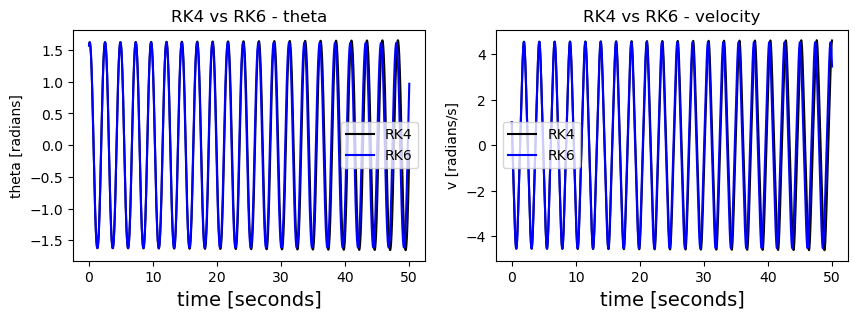

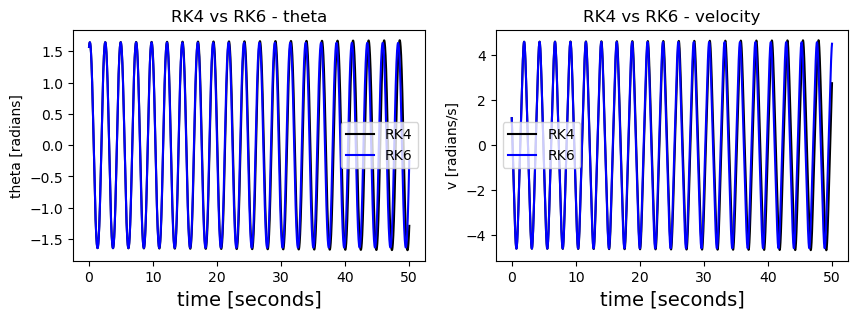

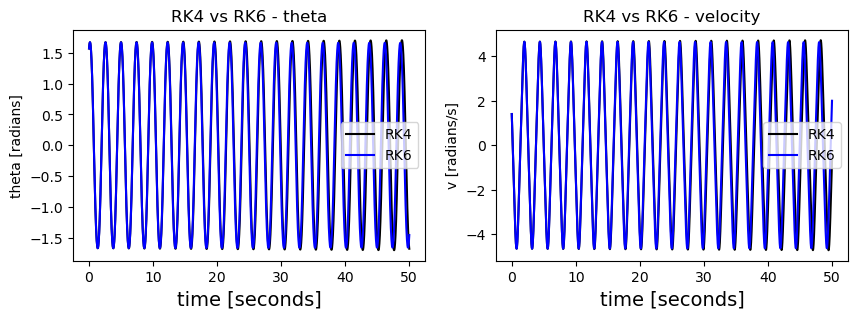

In [35]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t1,theta1,v1,E1 = RK4(50,np.pi/2,i,1,0.0001)
    t2,theta2,v2, E2 = RK6(50,np.pi/2,i,1,0.0001)

    plt.figure(figsize = (10,3))

    plt.subplot(1,2,1)
    plt.title('RK4 vs RK6 - theta')
    plt.plot(t1,theta1, label = 'RK4', color = 'black')
    plt.plot(t2,theta2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title('RK4 vs RK6 - velocity')
    plt.plot(t1,v1, label = 'RK4', color = 'black')
    plt.plot(t2,v2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('v [radians/s]')    

    plt.legend()
    plt.show()

# Energy comparison for different initial angles - RK4 v RK6

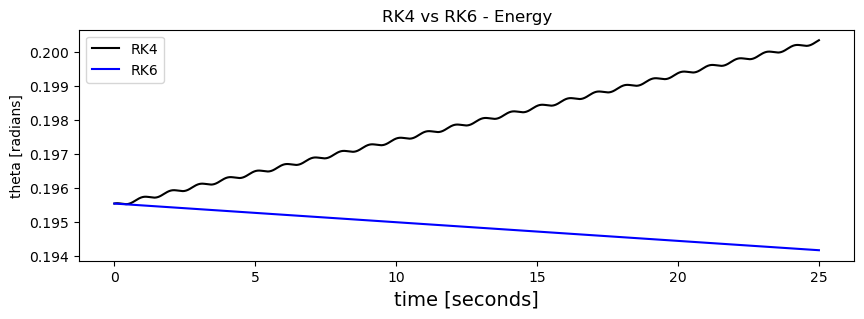

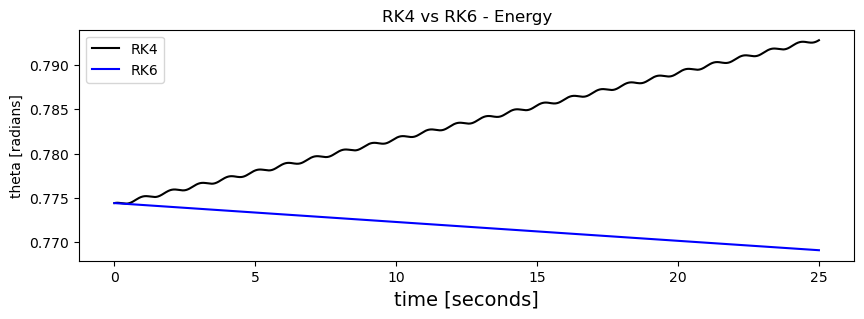

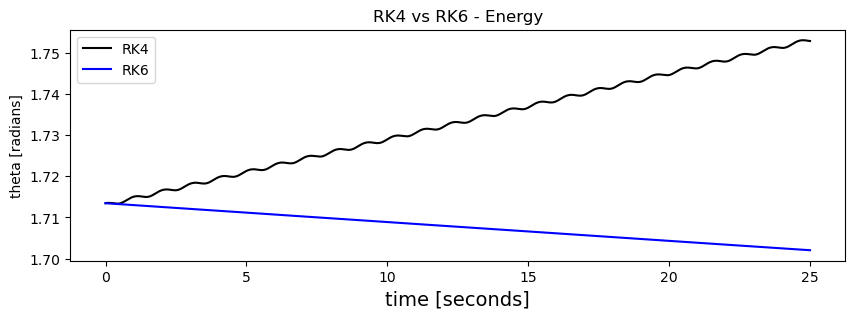

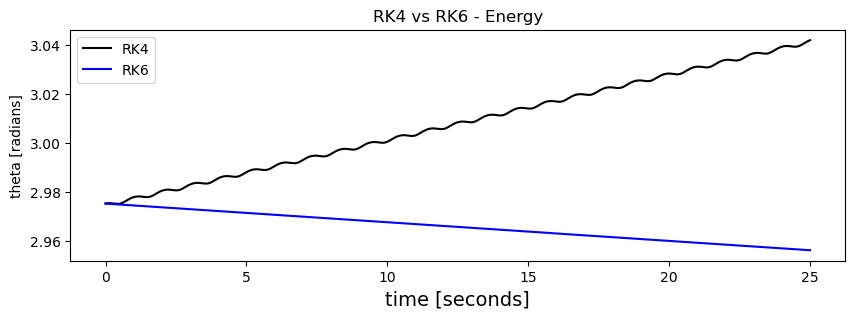

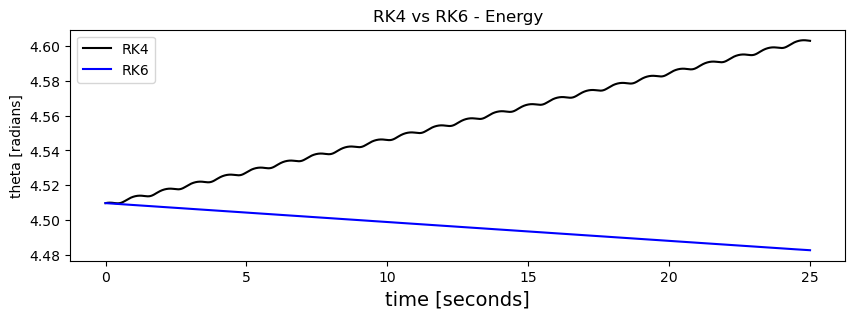

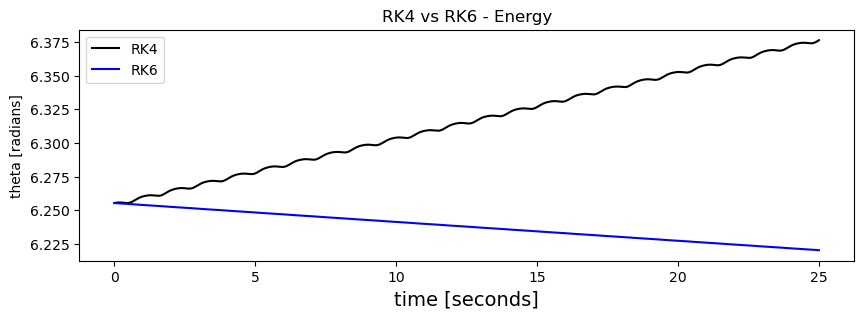

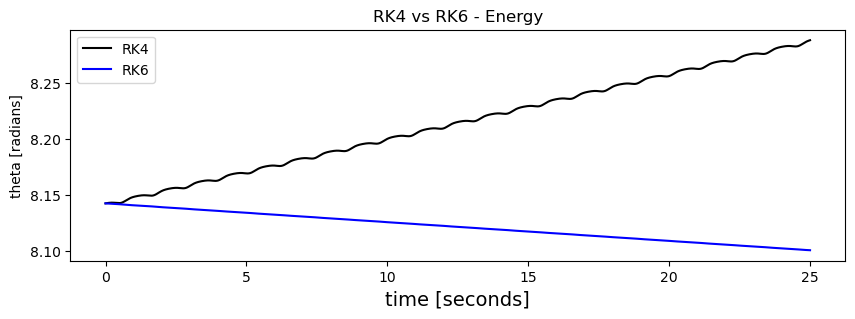

In [37]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t1,theta1,v1,E1 = RK4(25,i,0,1,0.0001)
    t2,theta2,v2, E2 = RK6(25,i,0,1,0.0001)

    plt.figure(figsize = (10,3))
    plt.title('RK4 vs RK6 - Energy')
    plt.plot(t1,E1, label = 'RK4', color = 'black')
    plt.plot(t2,E2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()

    plt.show()

# Energy comparison for different velocities - RK4 v RK6

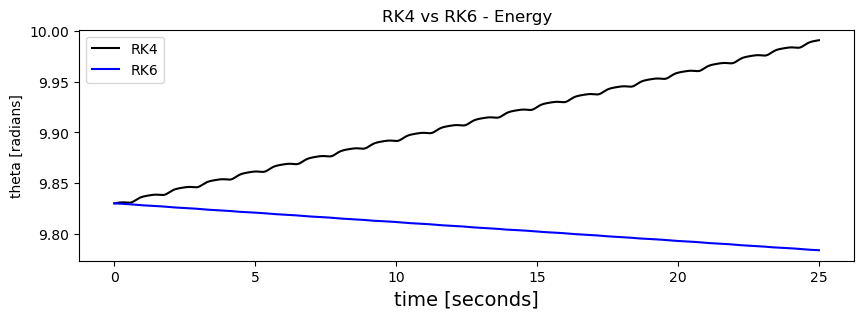

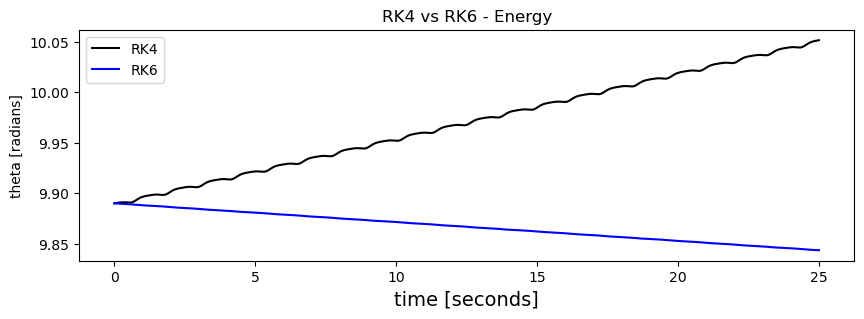

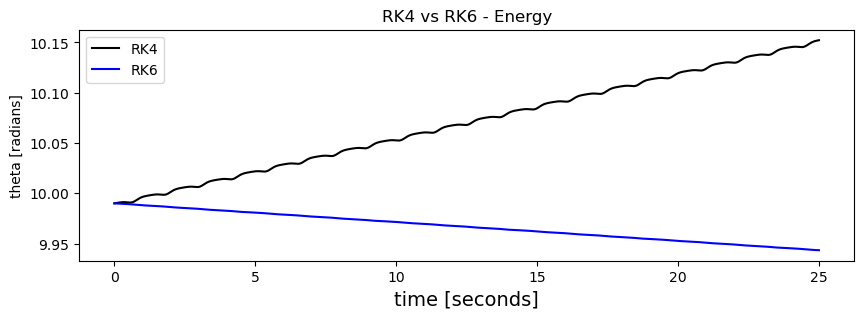

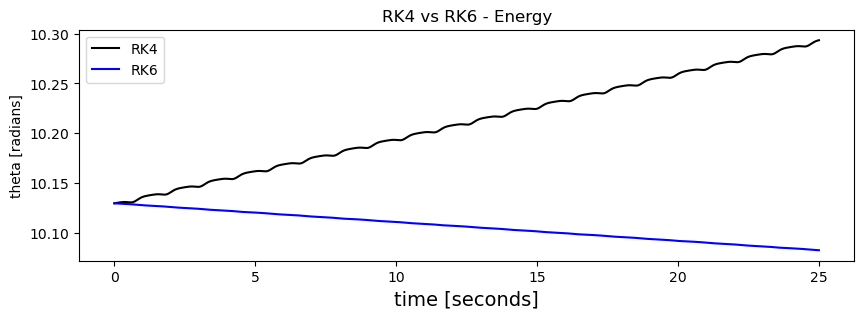

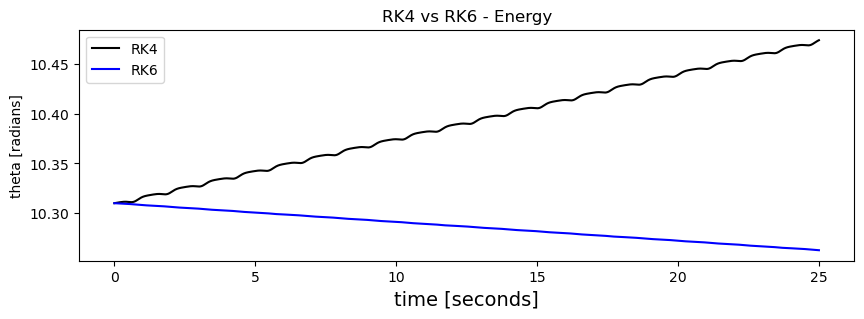

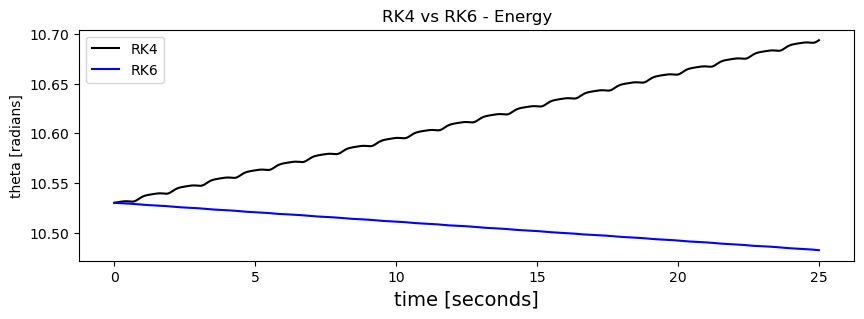

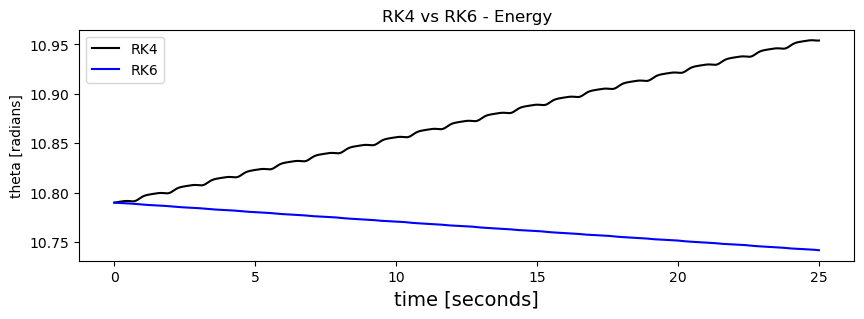

In [36]:
for i in [0.2,0.4,0.6,0.8,1.0,1.2,1.4]:

    t1,theta1,v1,E1 = RK4(25,np.pi/2,i,1,0.0001)
    t2,theta2,v2, E2 = RK6(25,np.pi/2,i,1,0.0001)

    plt.figure(figsize = (10,3))
    plt.title('RK4 vs RK6 - Energy')
    plt.plot(t1,E1, label = 'RK4', color = 'black')
    plt.plot(t2,E2, label = 'RK6', color = 'blue')
    plt.xlabel('time [seconds]', size = 14)
    plt.ylabel('theta [radians]')
    plt.legend()

    plt.show()